In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import scanpy as sc

import os

import scvi

import seaborn as sns

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [23]:
scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))


colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, colors_list))

# RNA clustering

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')

union_bc_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_bc_df = pd.read_csv(union_bc_file,  sep='\t', index_col=0)
union_bc_df.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


In [3]:
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')
h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [5]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
SCVI_LATENT_KEY = "RNA_scVI"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI"


print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

Save integrated samples into .h5ad file and trained SCVI model into subfolder

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [7]:
h5_rna_union.layers['log1p_counts'] = np.log1p(h5_rna_union.X)
h5_rna_union.layers['cpm'] = sc.pp.normalize_total(h5_rna_union, target_sum=1e4, inplace=False)['X']
h5_rna_union.layers['log1p_cpm'] = np.log1p(h5_rna_union.layers['cpm'])

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


### Vis on RNA spcae

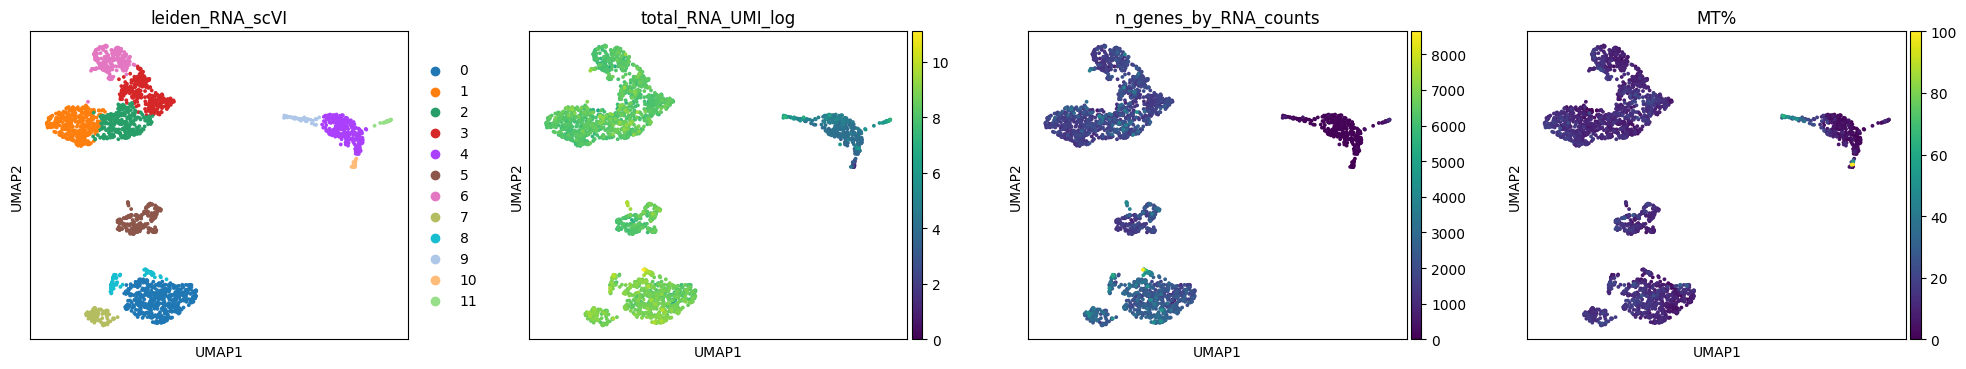

In [8]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI',  'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=4)

In [9]:
print('Total number of barcodes that pass at least one of the three ATAC-based filtering methods: ', union_bc_df.shape[0])
print('Among those barcodes, number of barcodes that has RNA information: ', h5_rna_union.shape[0])

Total number of barcodes that pass at least one of the three ATAC-based filtering methods:  2384
Among those barcodes, number of barcodes that has RNA information:  2381


In [10]:
# 3 cells do not have RNA info at all 
bc_wo_RNAinfo_list = union_bc_df.index[~union_bc_df.index.isin(h5_rna_union.obs['atac_barcodes'])]
union_bc_df.loc[bc_wo_RNAinfo_list]

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
CGAATAATCTCACTTC,1377,False,True,False,entropy_only,entropy_only,ACACTTAAGTGATTCA,False,0.169662,no_rna_info,NO,SADE unique
CGGTTTATCCTAAATC,1236,False,True,False,entropy_only,entropy_only,ATGGCTTAGGAGCAAC,False,0.242614,no_rna_info,NO,SADE unique
GTTAGGAGTGCTCATG,352,False,True,False,entropy_only,entropy_only,CCTGTAACAACTGGGA,False,0.087141,no_rna_info,NO,SADE unique


In [11]:
col_list = ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'Entropy', '_3set_identified_by_atac', 'DNA_debris']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_bc_df[col])

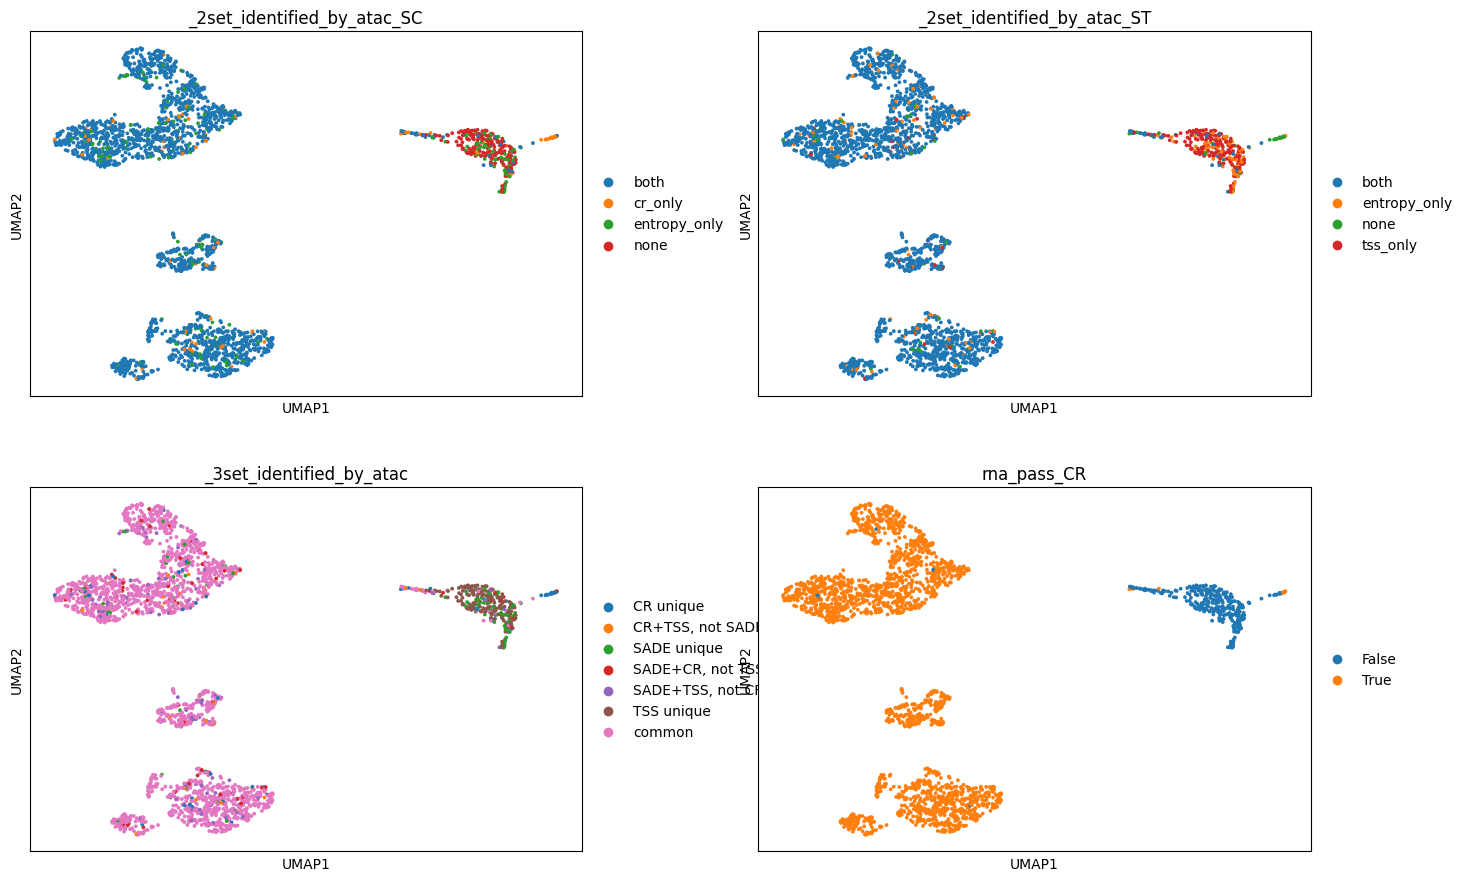

In [12]:

with plt.rc_context({'figure.figsize': (7, 5)}):
    sc.pl.umap(h5_rna_union, color=['_2set_identified_by_atac_SC',
                                    '_2set_identified_by_atac_ST', 
                                    '_3set_identified_by_atac',
                              'rna_pass_CR'], wspace=0.2, size=30, ncols=2)

<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

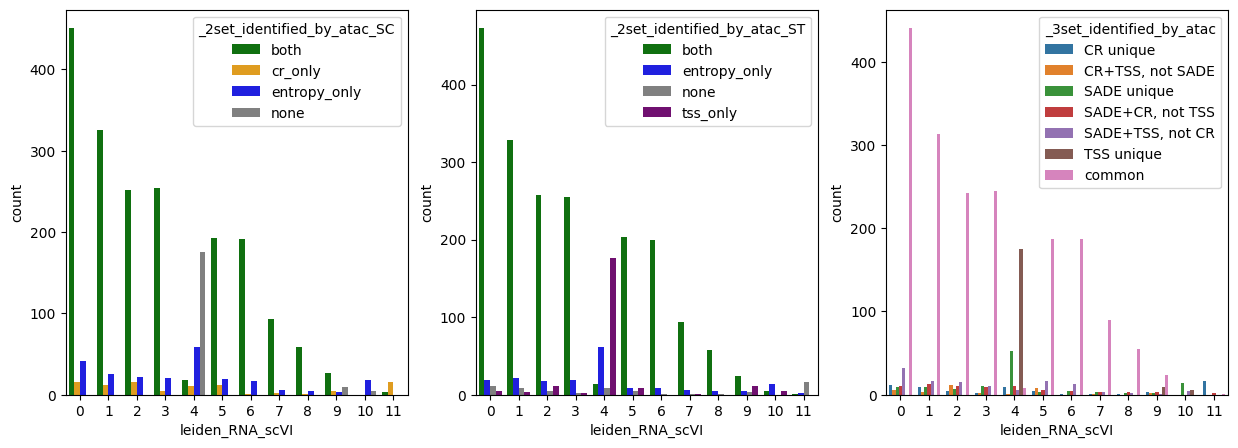

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
color_dic = {'both': 'green', 'entropy_only': 'blue', 'cr_only': 'orange',   'tss_only': 'purple', 'none': 'grey', '2 out of 3': 'cyan', 'all': 'red'}
sns.countplot(data=h5_rna_union.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_SC', palette=color_dic, ax=ax[0])
sns.countplot(data=h5_rna_union.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_ST', palette=color_dic, ax=ax[1])
sns.countplot(data=h5_rna_union.obs, x='leiden_RNA_scVI', hue='_3set_identified_by_atac',  ax=ax[2])


In [14]:
h5_rna_union.obs.head(2)

,rna_barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,Entropy,_3set_identified_by_atac,DNA_debris
AAACAGCCAGGCTACT-1,AAACAGCCAGGCTACT,ACAGCGGGTTTGTAGC,3931.0,8.276903,1772,519.0,13.202747,0,0,1,both,both,True,True,True,True,0.130478,common,NO
AAACATGCAAGGATTA-1,AAACATGCAAGGATTA,CATTTAGGTAACAGCA,3566.0,8.179481,1689,401.0,11.245092,0,0,3,both,both,True,True,True,True,0.197080,common,NO


# Bridge to ATAC QC metrics 

In [15]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)

h5_rna_union.obs['amulet_doublet_atac'] = h5_rna_union.obs['atac_barcodes'].isin(doublet_atac_barcodes['atac_bc'])

In [16]:
h5_rna_union.obs.groupby(['amulet_doublet_atac', 'DNA_debris']).size().unstack(fill_value=0) 

/tmp/ipykernel_3823584/727368809.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_union.obs.groupby(['amulet_doublet_atac', 'DNA_debris']).size().unstack(fill_value=0)


DNA_debris,NO,YES
amulet_doublet_atac,,
False,2283,2
True,76,20


In [17]:
h5_rna_union.obs['debris_doublets_flag'] = h5_rna_union.obs.apply(lambda row: 
    'debrisNdoublet' if row['DNA_debris'] == 'YES' and row['amulet_doublet_atac'] == True \
        else ('doublets' if row['amulet_doublet_atac'] == True \
            else ('Debris' if row['DNA_debris'] == 'YES' else 'clean')), axis=1)

/tmp/ipykernel_3823584/2991586895.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag'] == type].groupby(['leiden_RNA_scVI', '_3set_identified_by_atac'] ).size().unstack(fill_value=0)
/tmp/ipykernel_3823584/2991586895.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag'] == type].groupby(['leiden_RNA_scVI', '_3set_identified_by_atac'] ).size().unstack(fill_value=0)
/tmp/ipykernel_3823584/2991586895.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to T

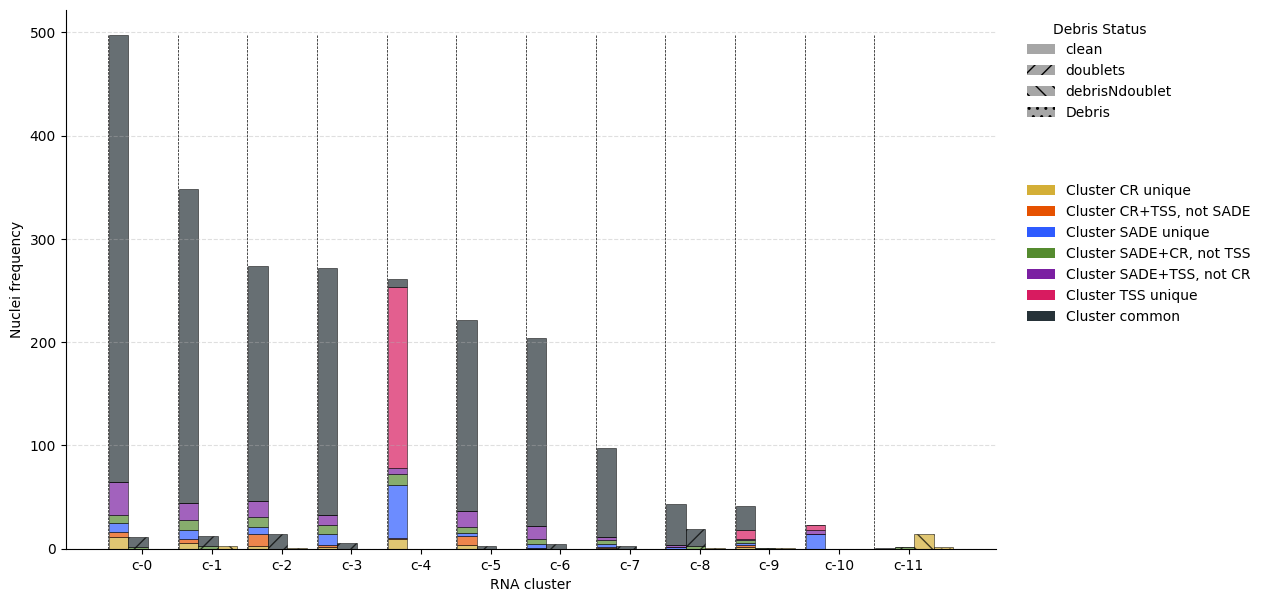

In [ ]:


flags = h5_rna_union.obs['debris_doublets_flag'].unique()
alpha_map = {f: a for f, a in zip(flags, [0.7, 0.7, 0.7, 0.7])}
hatch_map = {f: h for f, h in zip(flags, ['', '//', '\\\\', '..'])}

fig, ax = plt.subplots(figsize=(12, 7))
group_spacing = 2.5 
width = 0.7
legend_handles = {}

for i, type in enumerate(h5_rna_union.obs['debris_doublets_flag'].unique()):

    df = h5_rna_union.obs[h5_rna_union.obs['debris_doublets_flag'] == type].groupby(['leiden_RNA_scVI', '_3set_identified_by_atac'] ).size().unstack(fill_value=0)

    x_positions = np.arange(len(df)) * group_spacing + 0.7 * i  # 1.5 spacing instead of 1.0

    # 2. Filter: Only keep X-axis categories (columns) that have a total count > 0
    pivot_df = df.loc[:, df.sum(axis=0) > 0]

    bottom = np.zeros(len(pivot_df))

    # # 5. Iterate through each cluster (the stack variable)
    # # We only plot clusters that actually have cells (non-zero frequencies)
    for cluster in pivot_df.columns:
        heights = pivot_df[cluster].values
        
        if heights.sum() > 0:  # Only add to plot if the cluster exists in the data
            color = cat_colors_map.get(str(cluster), 'red')

            bar = ax.bar(x_positions, 
                heights, 
                bottom=bottom, 
                label=f"{cluster}", 
                color=color,
                width=width, 
                alpha=alpha_map[type],
                hatch=hatch_map[type],
                edgecolor='black',
                linewidth=0.5)
            
            if cluster not in legend_handles:
                legend_handles[cluster] = Patch(facecolor=color, label=f"Cluster {cluster}")
            bottom += heights
    if i == 0:  # Add flag legend only once
        ax.vlines(x_positions - width/2 * 1.1, 0, bottom.max(), color='black', linestyle='--', linewidth=0.5)

flag_elements = [Patch(facecolor='gray', alpha=alpha_map[f], hatch=hatch_map[f], label=f) for f in flags]
leg_flags = ax.legend(handles=flag_elements, title="Debris Status", 
                      bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.add_artist(leg_flags)

# Legend 2: RNA Clusters (Numerical Sort)
sorted_keys = sorted(legend_handles.keys(), key=lambda x: int(x) if str(x).isdigit() else 99)
sorted_handles = [legend_handles[k] for k in sorted_keys]

ax.legend(handles=sorted_handles, title="", 
          bbox_to_anchor=(1.02, 0.70), loc='upper left', ncol=1, frameon=False)

## 
ax.set_xticks(x_positions - group_spacing/2)  # Center the ticks between groups
ax.set_xticklabels(['c-' + str(label) for label in pivot_df.index], rotation=0, ha='center')

ax.set_ylabel("Nuclei frequency")
ax.set_xlabel("RNA cluster")
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


In [21]:
mono = ['CD14',   'HLA-DRA',  'LYZ', 'TNF', 'IL1B']
NK = [  'CD3D', 'KLRG1',   'NCR3','KLRB1', 'NKG7']
gamma_delta_T = ['TRDC',   'TRGC1','TRDV2', 'TRGV9']
B_cell = ['MS4A1']
housekeeping_genes = ['GNB1','CMPK1', 'PRPF38B',  'CDC42SE1', 'PPP2R5A', 'COX7A2L', 'SF3B1', 'CTDSP1']
marker_genes = ['LEF1',  'TREM1',  'PPBP'] + B_cell + mono + NK + gamma_delta_T + housekeeping_genes

marker_genes_redor = ['LYZ', 'HLA-DRA', 'LEF1', 'NKG7','CD3D', 'MS4A1', 
                      
                      'CD14', 'TREM1', 'KLRB1', 'KLRG1', 'TRDC', 'TRGC1', 'NCR3', 'IL1B', 
                      'TRGV9', 'TNF', 'PPBP', 'TRDV2', 
                      
                      'GNB1','CMPK1', 'PRPF38B',  'CDC42SE1', 'PPP2R5A', 'COX7A2L', 'SF3B1', 'CTDSP1'
                      ]

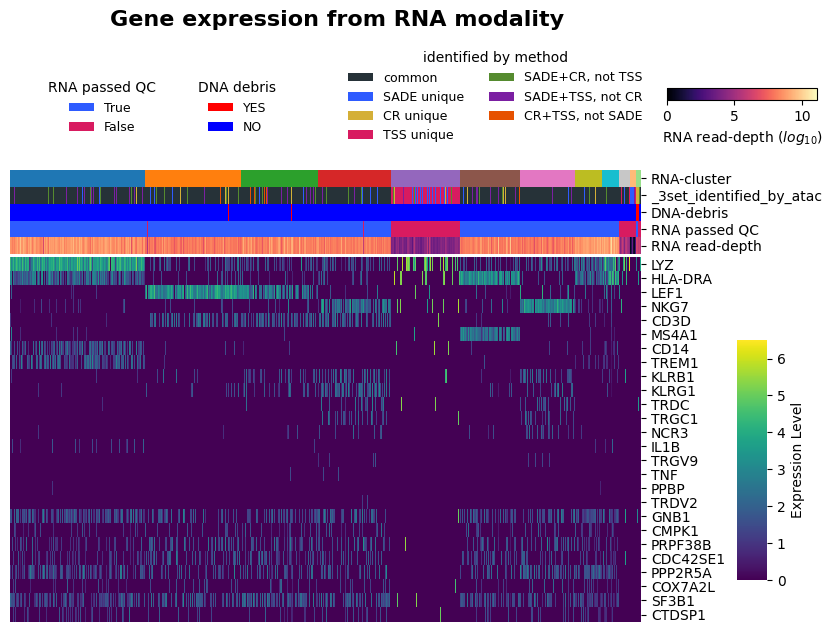

In [42]:
# rows being markergens 
# columns-1 being leiden clusters
# columns-2 being the 3-set classification (e.g. 2-set identified by ATAC SC, 2-set identified by ATAC ST, 3-set identified by ATAC)
# columns-3 being pass CR preproessing or not
h5_rna_union.var_names_make_unique()

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, colors_list))                  

pass_cr_map = {True: '#2E5BFF', False: '#D81B60'}
dna_debris_map = {'YES': 'red', 'NO': 'blue'}

data = h5_rna_union[:, marker_genes_redor].layers['log1p_cpm'].toarray()
df = pd.DataFrame(data, index=h5_rna_union.obs.index, columns= marker_genes_redor).T

#Create metadata for the columns
metadata = h5_rna_union.obs[['leiden_RNA_scVI', '_3set_identified_by_atac', 'DNA_debris', 'rna_pass_CR', 'total_RNA_UMI_log']].copy()

cell_index = h5_rna_union.obs['leiden_RNA_scVI'].sort_values().index


norm = mcolors.Normalize(vmin=metadata['total_RNA_UMI_log'].min(), vmax=metadata['total_RNA_UMI_log'].max())
mapper = cm.ScalarMappable(norm=norm, cmap='magma')
col_colors = pd.DataFrame({
    'RNA-cluster': metadata['leiden_RNA_scVI'].map(scanpy_color_map),
    '_3set_identified_by_atac': metadata['_3set_identified_by_atac'].map(cat_colors_map),
    'DNA-debris': metadata['DNA_debris'].map(dna_debris_map),
    'RNA passed QC': metadata['rna_pass_CR'].map(pass_cr_map),
    'RNA read-depth': metadata['total_RNA_UMI_log'].apply(lambda x: mcolors.to_hex(mapper.to_rgba(x))), 
}, index=metadata.index)

# 4. Plot the clustermap
g = sns.clustermap(df.loc[:, cell_index], col_colors=col_colors.loc[cell_index], cmap='viridis', #cmap='seismic', 
                   figsize=(10, 6), col_cluster=False, xticklabels=False, row_cluster=False,  yticklabels=True,
                   cbar_pos=(0.9, 0.1, 0.03, 0.4), # Horizontal bar at bottom center
                   cbar_kws={"orientation": "vertical", 'label': 'Expression Level'}, 
                  )
g.ax_row_dendrogram.set_visible(False) # Hide Row tree

umi_cax = g.fig.add_axes([0.83, 0.9, 0.15, 0.02]) 
cb = plt.colorbar(mapper, cax=umi_cax, orientation='horizontal', label='RNA read-depth ($log_{10}$)')



# Legend for 'rna_pass_CR'
pass_cr_handles = [
    Patch(facecolor=color, label=str(label)) 
    for label, color in pass_cr_map.items()
]
g.fig.legend(
    handles=pass_cr_handles,
    title='RNA passed QC',
    bbox_to_anchor=(0.2, 0.95), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9
)
# Legend for 'DNA_debris'
dna_debris_handles = [
    Patch(facecolor=color, label=str(label))
    for label, color in dna_debris_map.items()
]
g.fig.legend(
    handles=dna_debris_handles,
    title='DNA debris',
    bbox_to_anchor=(0.35, 0.95), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9
)

g.fig.suptitle('Gene expression from RNA modality',
               fontsize=16, 
               fontweight='bold', 
               y=1.05) #

# legend for '_3set_identified_by_atac'
atac_set_handles = [
    Patch(facecolor=color, label=label)
    for label, color in cat_colors_map.items()
]
g.fig.legend(
    handles=atac_set_handles,
    title='identified by method',
    bbox_to_anchor=(0.5, 1), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9,
    ncol=2
)

In [ ]:
# Save index for ATAC heat map plot's consistency
h5_rna_union.obs.loc[cell_index, ['rna_barcodes', 'atac_barcodes']].to_csv(os.path.join(Union_cell_subdir, '_unioncell_rna_order_index.csv')) 

In [24]:
h5_rna_union.obs.groupby(['DNA_debris', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_3015293/399134367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_union.obs.groupby(['DNA_debris', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,2,3,4,5,6,7,8,9,10,11
DNA_debris,,,,,,,,,,,,
NO,508,360,288,278,261,224,209,101,62,42,23,3
YES,0,3,1,0,0,0,0,0,1,1,0,16


In [24]:
# The standard "Scanpy / Vega / Tableau 20" list
scanpy_20 = [
    '#1f77b4', '#aec7e8', # Blue pair
    '#ff7f0e', '#ffbb78', # Orange pair
    '#2ca02c', '#98df8a', # Green pair
    '#d62728', '#ff9896', # Red pair
    '#9467bd', '#c5b0d5', # Purple pair
    '#8c564b', '#c49c94', # Brown pair
    '#e377c2', '#f7b6d2', # Pink pair
    '#7f7f7f', '#c7c7c7', # Grey pair
    '#bcbd22', '#dbdb8d', # Olive pair
    '#17becf', '#9edae5'  # Cyan pair
]
scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))

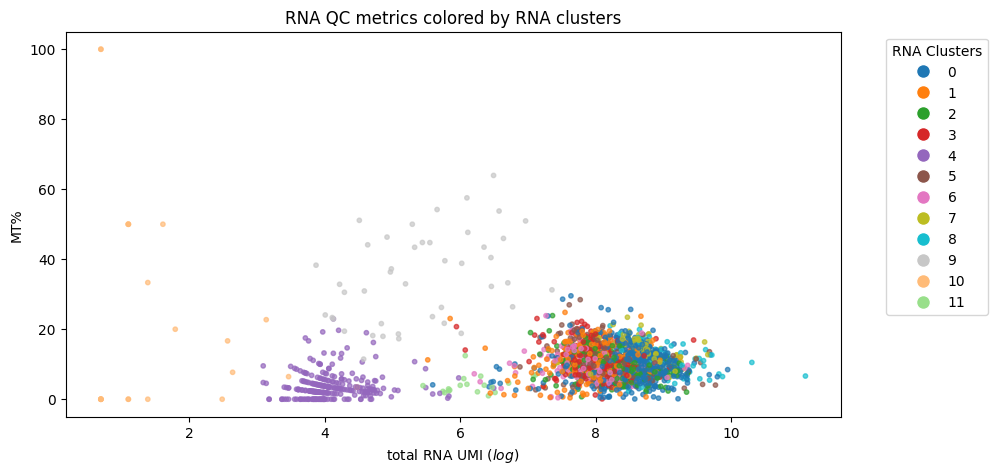

In [30]:
colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
colors_map = dict(zip(unique_categories, colors_list))                  
labels_map = dict(zip(unique_categories, unique_categories))

fig, ax = plt.subplots(figsize=(10, 5))
_ = ax.scatter(h5_rna_union.obs['total_RNA_UMI_log'], h5_rna_union.obs['MT%'], c=h5_rna_union.obs['leiden_RNA_scVI'].map(scanpy_color_map), alpha=0.7, s=10)
ax.set_xlabel('total RNA UMI ($log$)')
ax.set_ylabel('MT%')
ax.set_title('RNA QC metrics colored by RNA clusters')
legend_elements = [Line2D([0], [0], marker='o', color='w', label=cluster, markerfacecolor=color, markersize=10) for cluster, color in scanpy_color_map.items()]
ax.legend(handles=legend_elements, title='RNA Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

In [13]:
union_bc_df['leiden_RNA_scVI'] = union_bc_df.index.map(h5_rna_union.obs.set_index('atac_barcodes')['leiden_RNA_scVI'])
union_bc_df['leiden_RNA_scVI'] = union_bc_df['leiden_RNA_scVI'].cat.add_categories('no_rna_info')
union_bc_df['leiden_RNA_scVI'] = union_bc_df['leiden_RNA_scVI'].fillna('no_rna_info')

union_bc_df['leiden_RNA_scVI'].value_counts()

leiden_RNA_scVI
0              508
1              363
2              289
3              278
4              261
5              224
6              209
7              101
8               63
9               43
10              23
11              19
no_rna_info      3
Name: count, dtype: int64

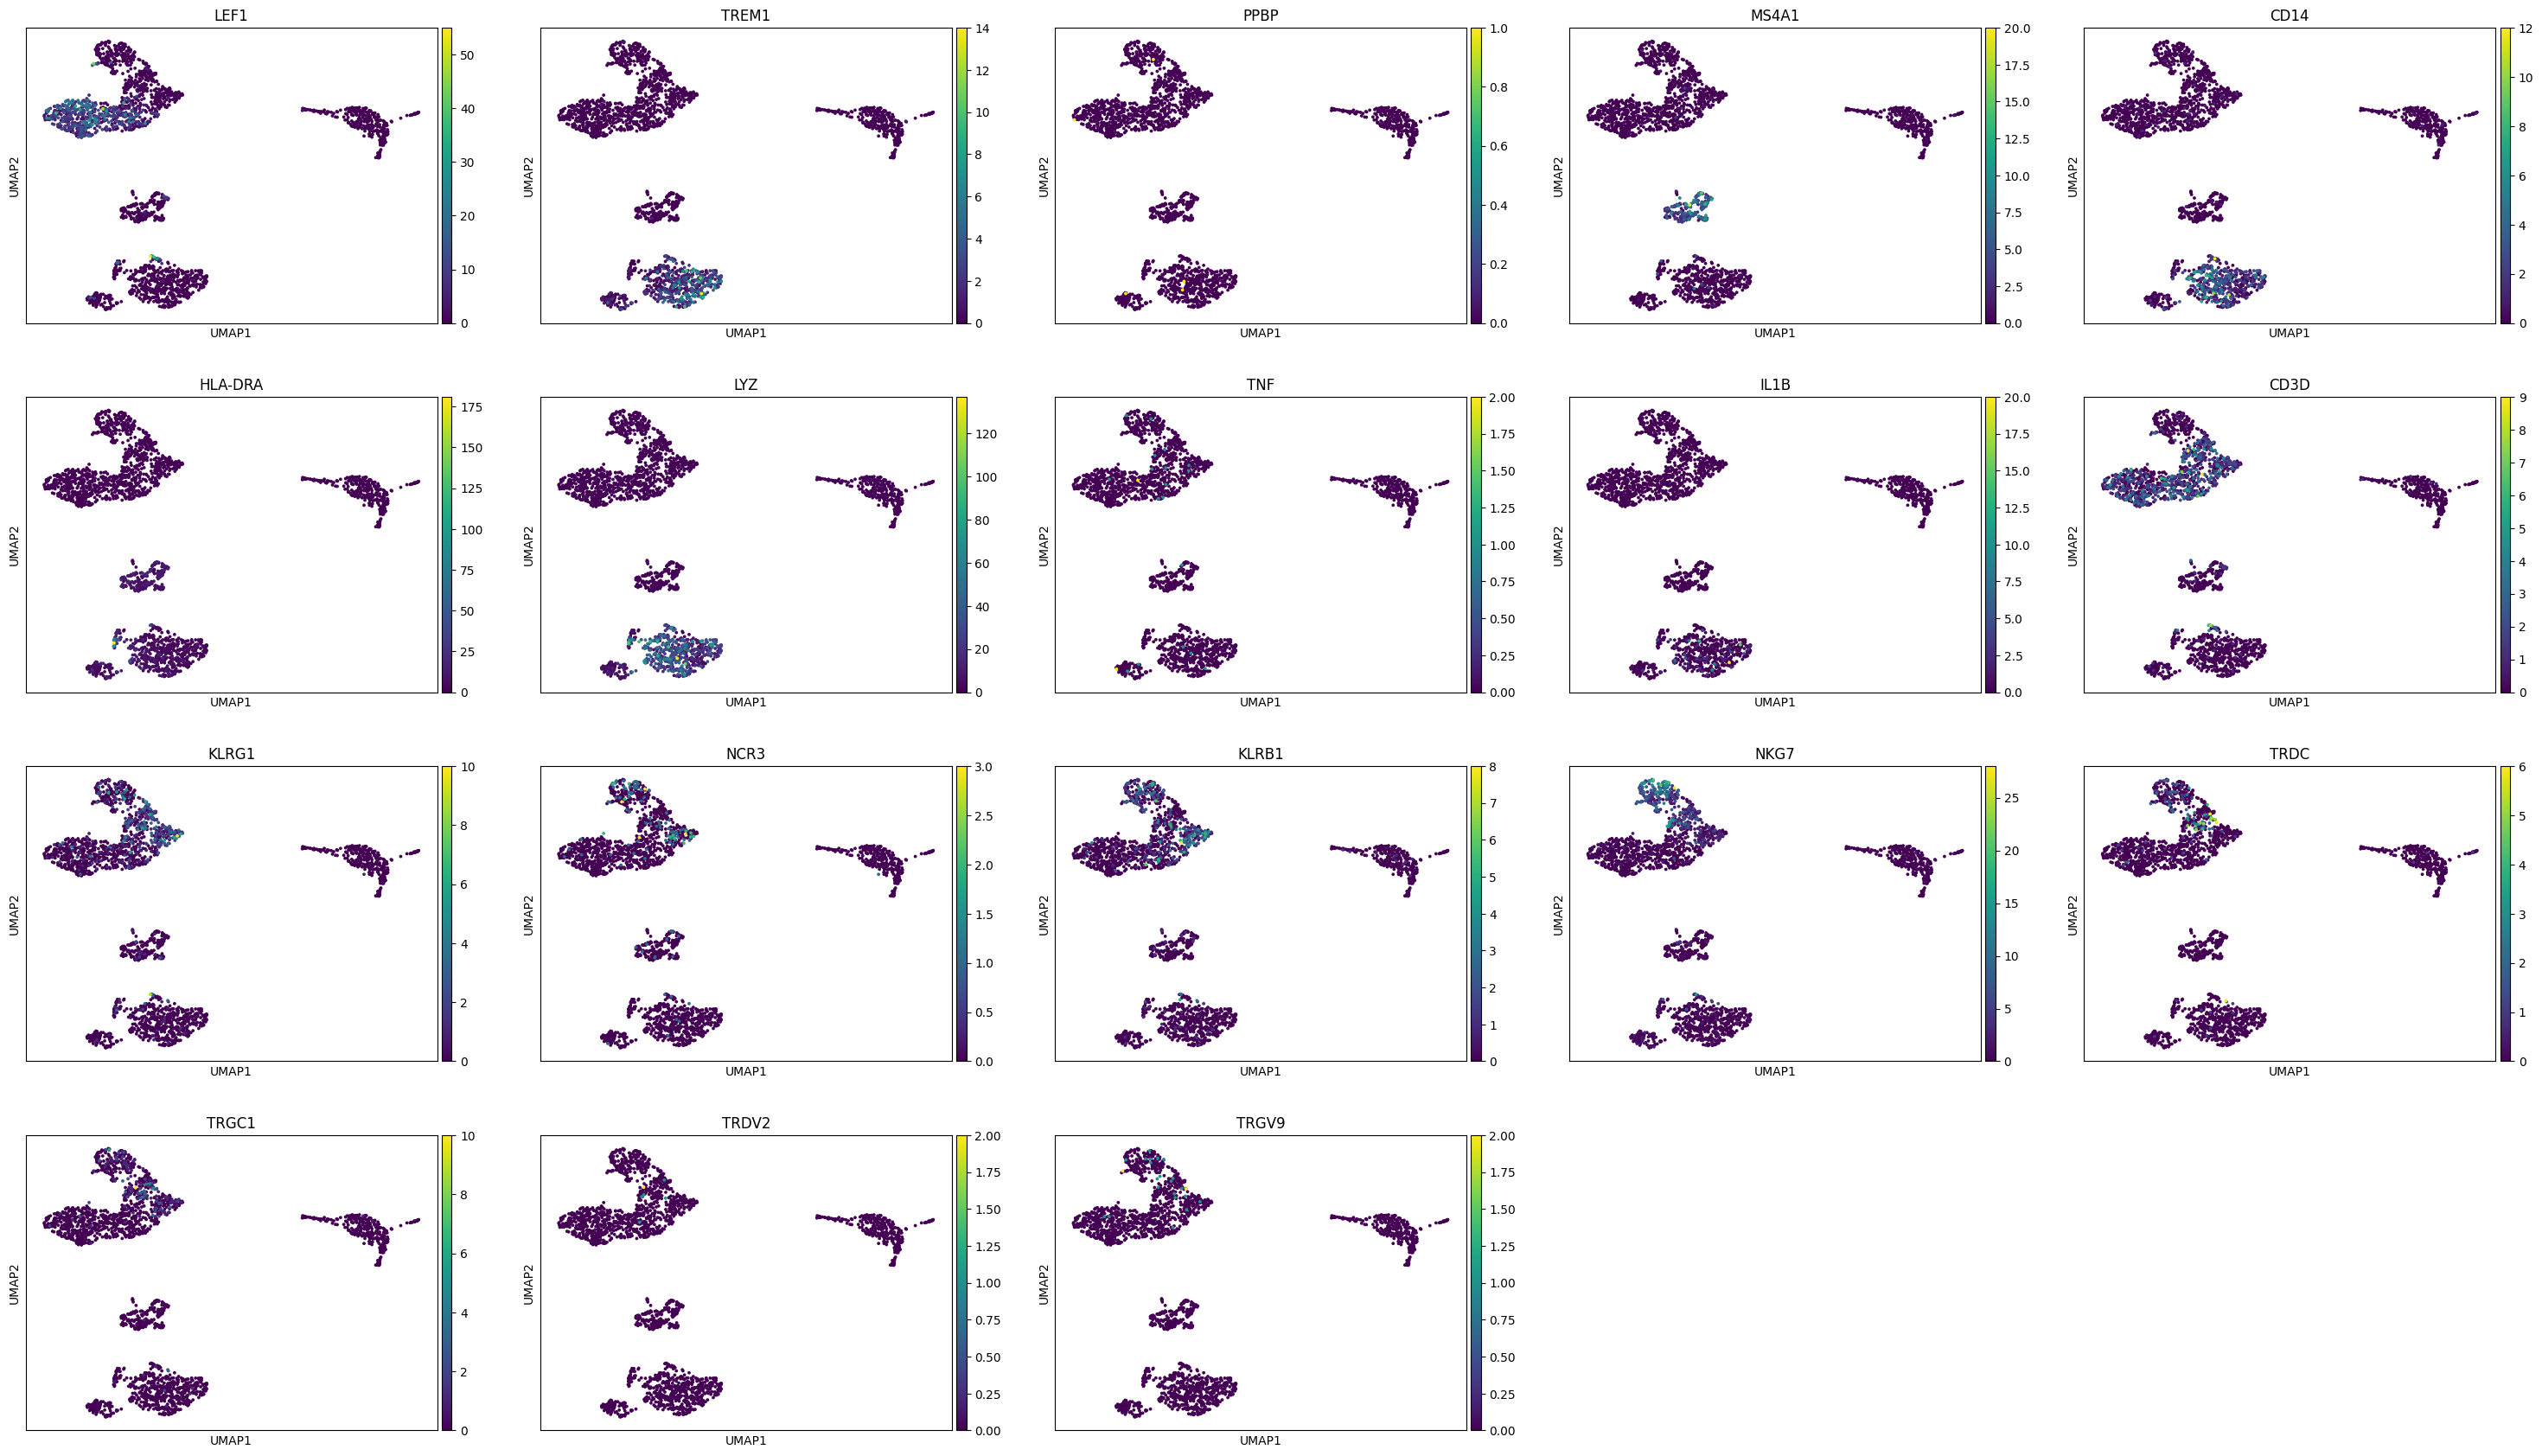

In [58]:
sc.pl.umap(h5_rna_union, color=marker_genes,  size=30, ncols=5)

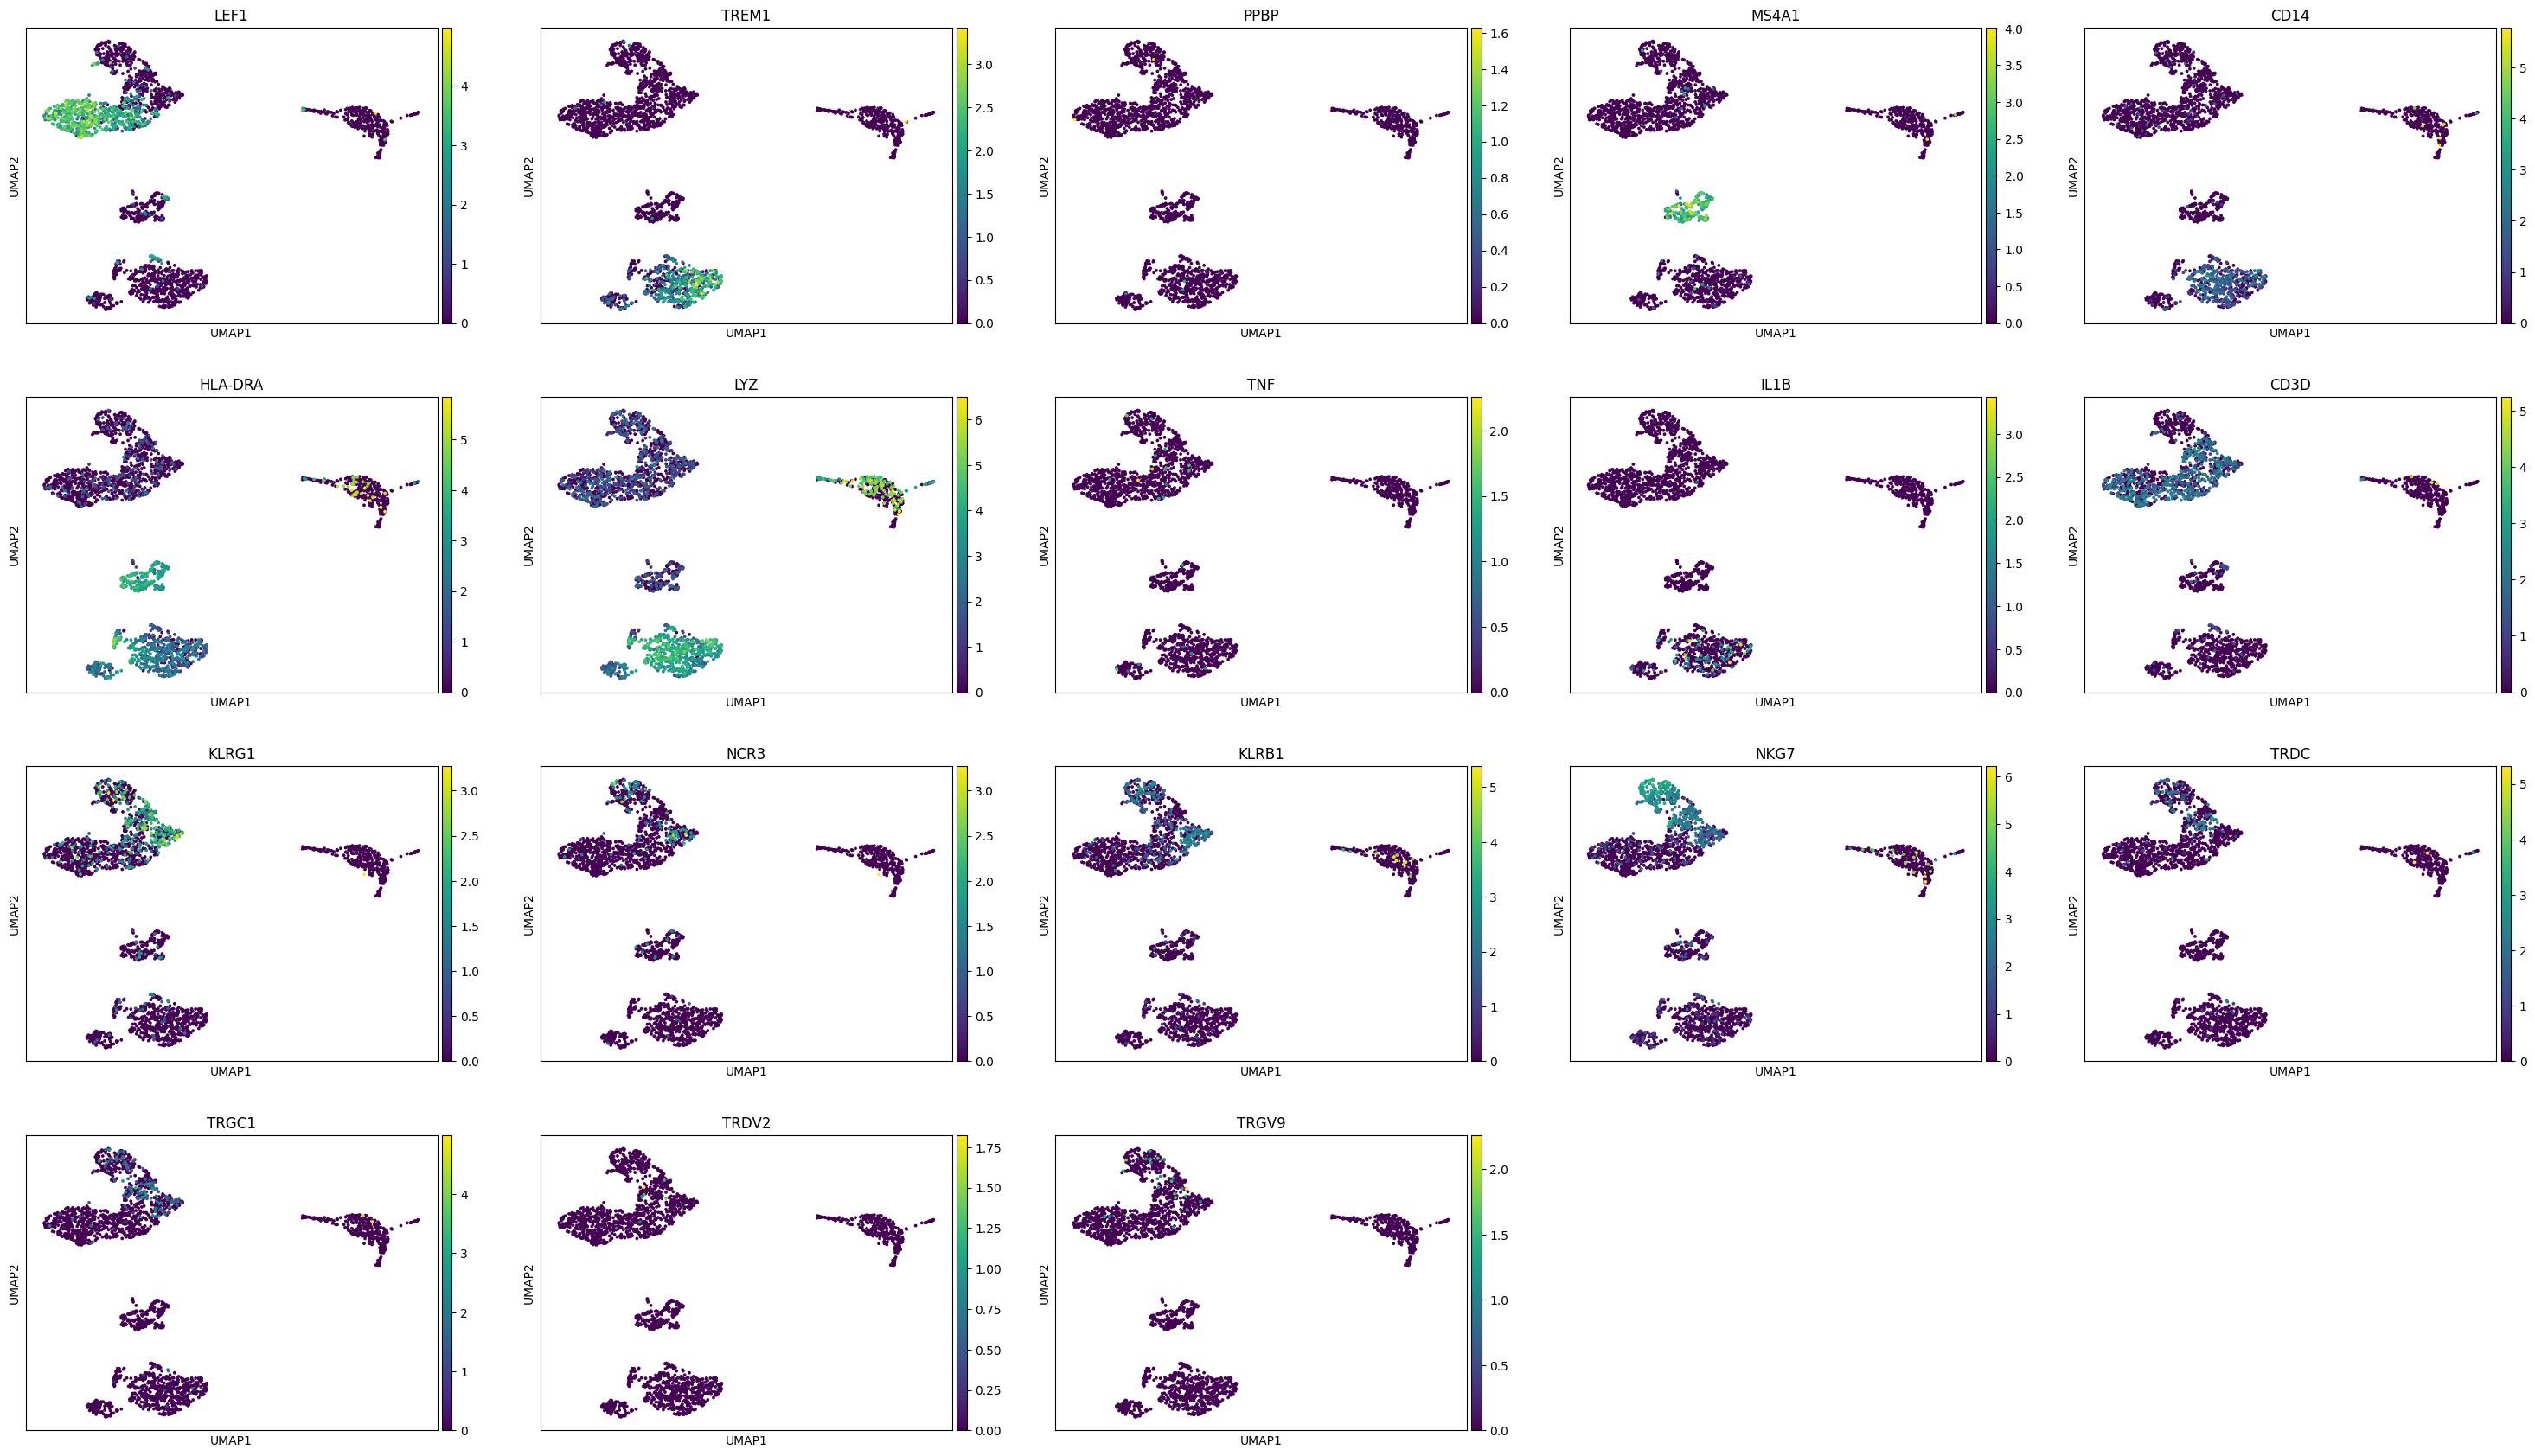

In [60]:
sc.pl.umap(h5_rna_union, color=marker_genes,  layer='log1p_cpm', size=30, ncols=5)

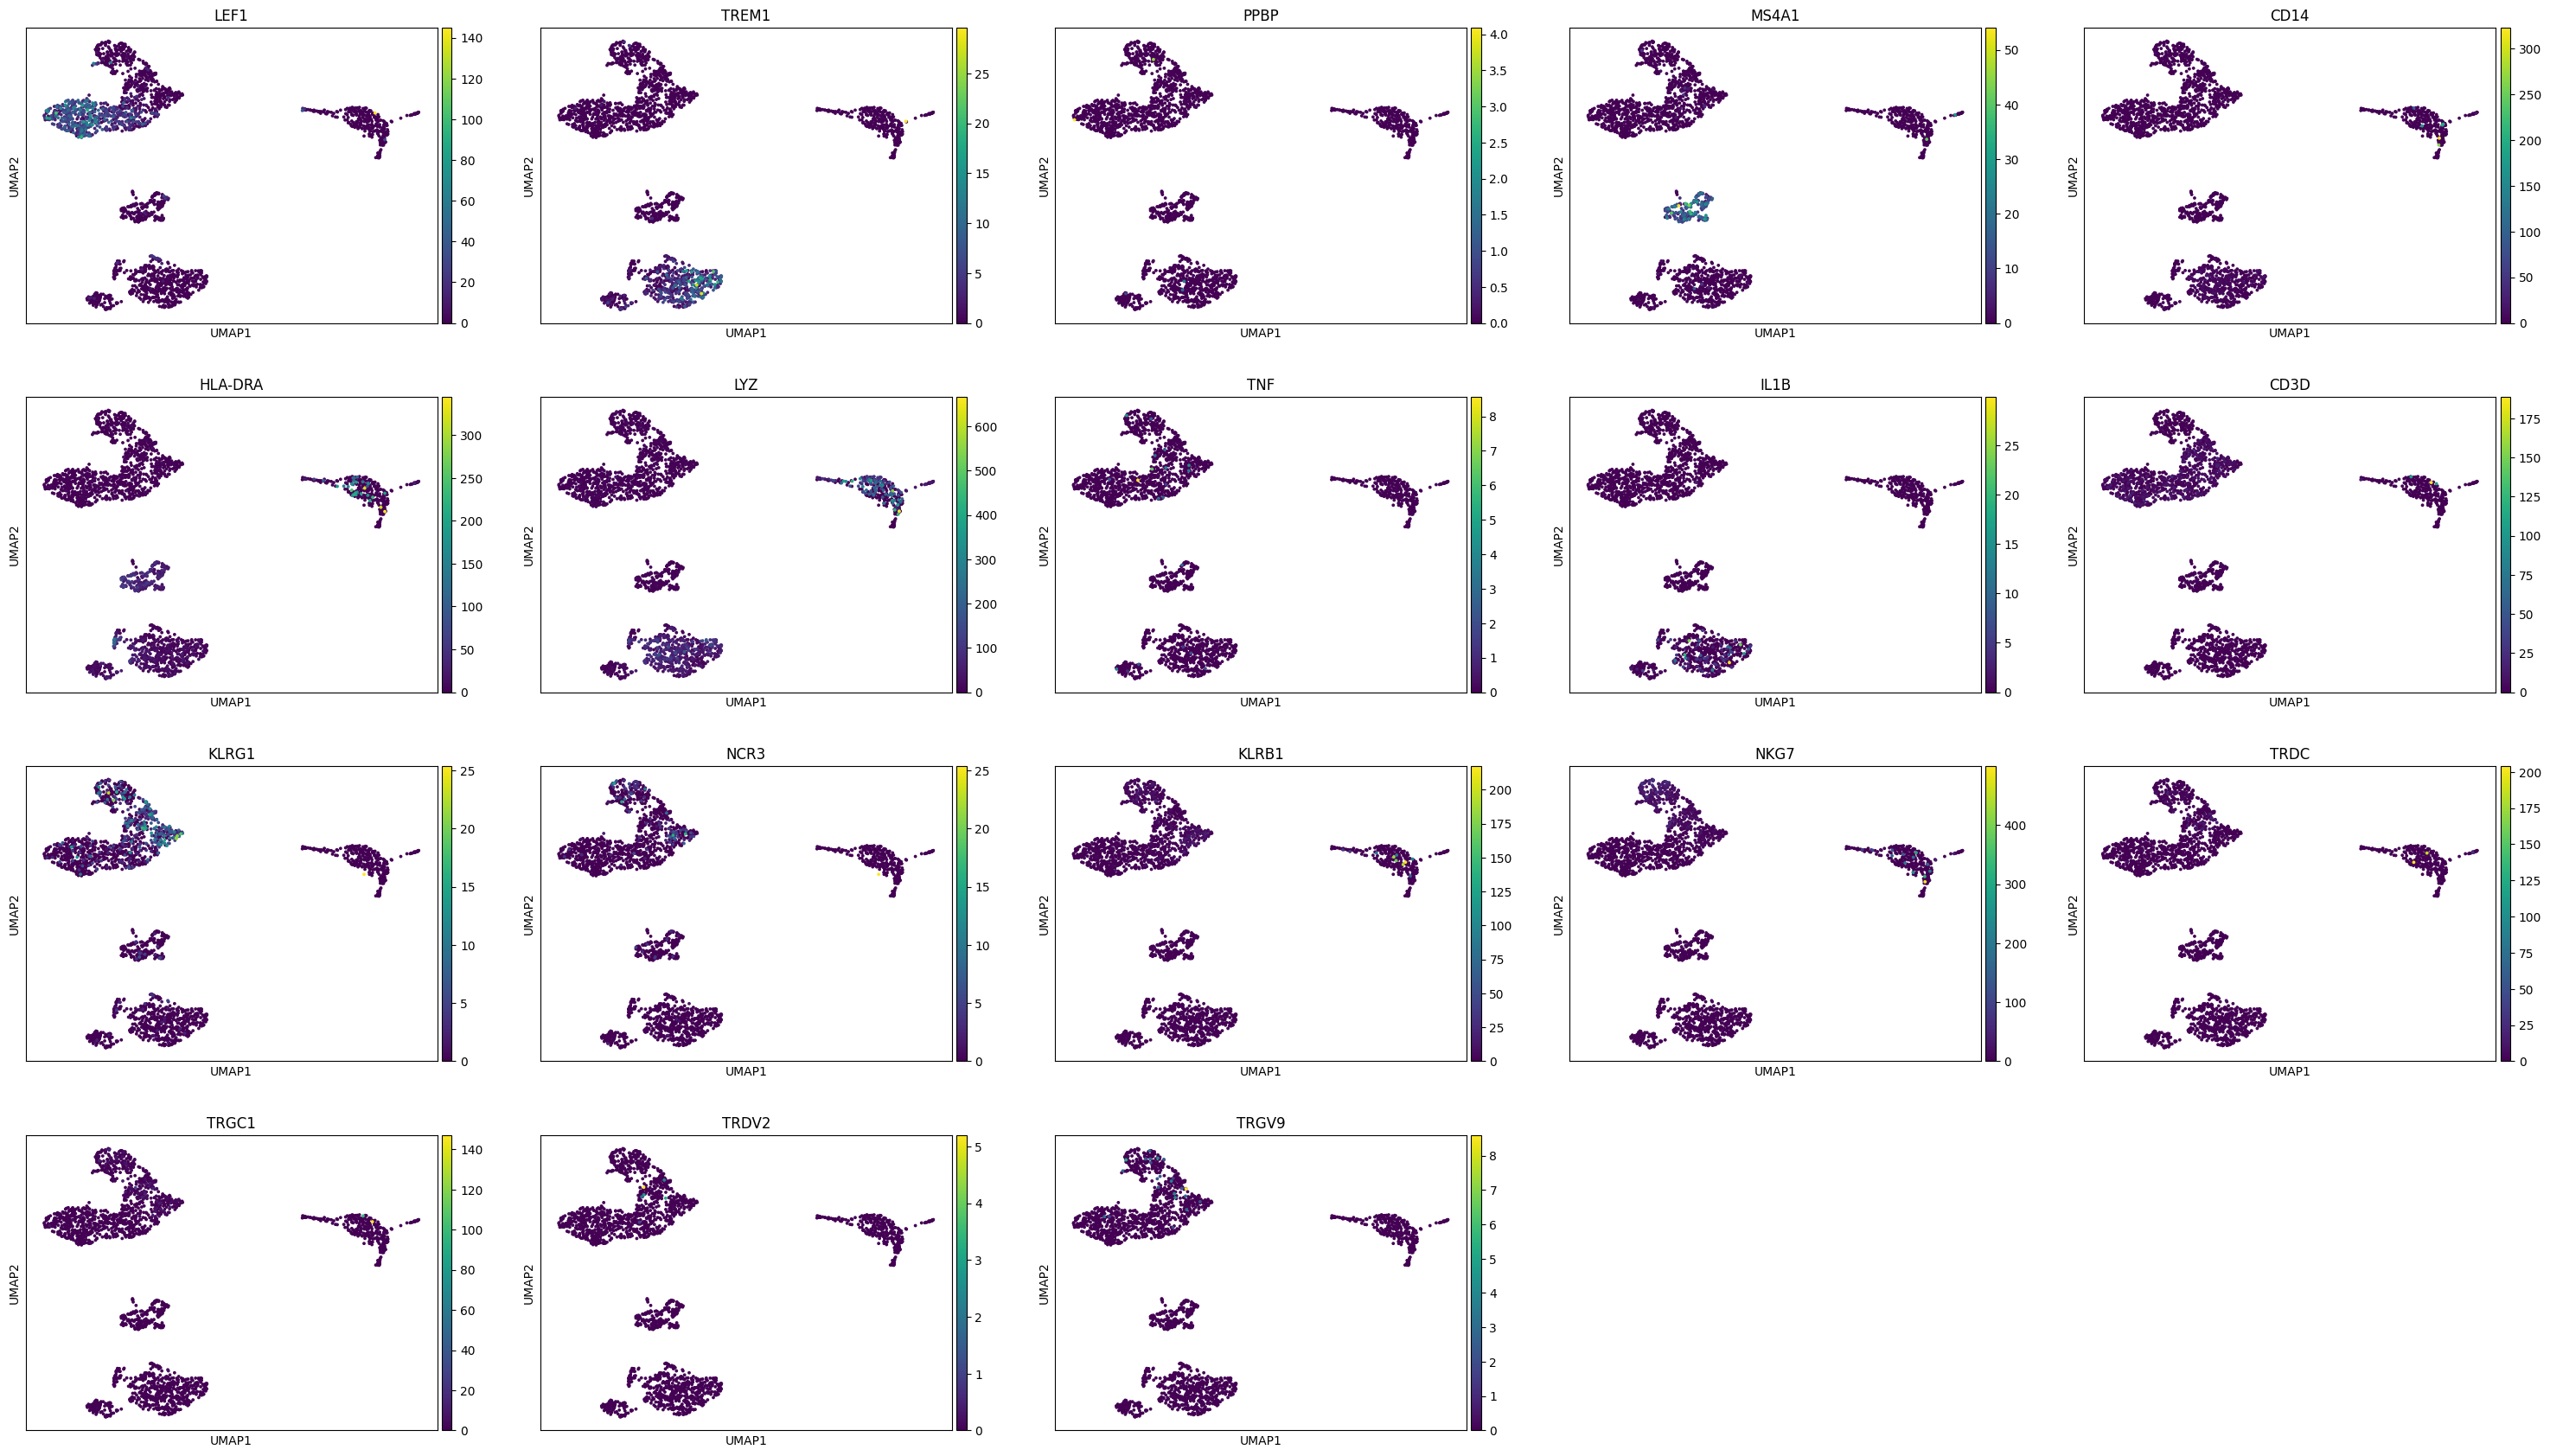

In [59]:

sc.pl.umap(h5_rna_union, color=marker_genes,  layer='cpm', size=30, ncols=5)